In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import missingno as msno
!pip install category_encoders
import sys
if 'google.colab' in sys.modules:
    !pip install -q dtreeviz
import dtreeviz
import seaborn as sns
sns.set(
    { "figure.figsize": (6, 4) },
    style='ticks',
    color_codes=True,
    font_scale=0.8
)
%config InlineBackend.figure_format = 'retina'
import warnings
warnings.filterwarnings('ignore')
sns.set_style('ticks')
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from sklearn.metrics import PredictionErrorDisplay, balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay,mean_absolute_error
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler, FunctionTransformer, OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold, cross_validate
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_text
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from category_encoders import TargetEncoder
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn import set_config
set_config(transform_output='pandas')

In [3]:
# Read the CSV file into a DataFrame named AT
AT = pd.read_csv('/content/drive/MyDrive/adverts.csv')

# Display the first few rows of the DataFrame
display(AT.head())

,public_reference,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
0,202006039777689,0.0,NaN,Grey,Volvo,XC90,NEW,NaN,73970,SUV,False,Petrol Plug-in Hybrid
1,202007020778260,108230.0,61,Blue,Jaguar,XF,USED,2011.0,7000,Saloon,False,Diesel
2,202007020778474,7800.0,17,Grey,SKODA,Yeti,USED,2017.0,14000,SUV,False,Petrol
3,202007080986776,45000.0,16,Brown,Vauxhall,Mokka,USED,2016.0,7995,Hatchback,False,Diesel
4,202007161321269,64000.0,64,Grey,Land Rover,Range Rover Sport,USED,2015.0,26995,SUV,False,Diesel


In [4]:
AT_copy = AT.copy()  # create a deep copy of AT

In [5]:
AT_demo = AT.copy()

In [6]:
# Get the number of rows and columns
num_rows, num_cols = AT.shape

print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_cols}")

Number of rows: 402005
Number of columns: 12


In [7]:
AT.describe().T

,count,mean,std,min,25%,50%,75%,max
public_reference,402005.0,2.020071e+14,1.691662e+10,2.013072e+14,2.020090e+14,2.020093e+14,2.020102e+14,2.020110e+14
mileage,401878.0,3.774360e+04,3.483172e+04,0.000000e+00,1.048100e+04,2.862950e+04,5.687575e+04,9.999990e+05
year_of_registration,368694.0,2.015006e+03,7.962667e+00,9.990000e+02,2.013000e+03,2.016000e+03,2.018000e+03,2.020000e+03
price,402005.0,1.734197e+04,4.643746e+04,1.200000e+02,7.495000e+03,1.260000e+04,2.000000e+04,9.999999e+06


## Visualize Data

In [ ]:
# Price distribution
sns.histplot(AT['price'], kde=True)
plt.title("Original Price Distribution")
plt.show()

print("Original Skew:", AT['price'].skew())

Since data is skewed lets use log transform on AT_demo and plot.

In [ ]:
AT_demo['price_log'] = np.log1p(AT['price'])

In [ ]:
sns.histplot(AT_demo['price_log'], kde=True)
plt.title("Log-Transformed Price Distribution")
plt.show()

print("Transformed Skew:", AT_demo['price_log'].skew())

In [ ]:
# Mileage distribution
plt.figure(figsize=(10,5))
sns.histplot(AT['mileage'], bins=100, kde=True)
plt.title('Mileage Distribution')
plt.xlim(0, 200000)
plt.show()

In [ ]:
# Price by vehicle_condition
plt.figure(figsize=(6,4))
sns.boxplot(x='vehicle_condition', y='price', data=AT)
plt.ylim(0, 200000)
plt.title('Price vs Vehicle Condition')
plt.show()

In [ ]:
# Price by fuel_type
plt.figure(figsize=(8,5))
sns.boxplot(x='body_type', y='price', data=AT)
plt.ylim(0, 200000)
plt.xticks(rotation=45)
plt.title('Price vs Fuel Type')
plt.show()

In [ ]:
# Top 20 models by median price
top_models = AT.groupby('standard_model')['price'].median().sort_values(ascending=False).head(20)
plt.figure(figsize=(12,5))
sns.barplot(x=top_models.index, y=top_models.values)
plt.xticks(rotation=90)
plt.title('Top 20 Models by Median Price')
plt.show()

In [ ]:
sns.scatterplot(x='mileage', y='price',hue='vehicle_condition', data=AT, alpha=0.5)
plt.xlim(0, 200000)
plt.ylim(0, 200000)
plt.title('Price vs Mileage')
plt.show()

In [ ]:
sns.scatterplot(x='mileage', y='price',hue='fuel_type', data=AT, alpha=0.5, palette='Paired')
plt.xlim(0, 200000)
plt.ylim(0, 200000)
plt.title('Price vs Mileage')
plt.show()

In [ ]:
sns.scatterplot(x='year_of_registration', y='price', data=AT, alpha=0.3)
plt.title('Price vs year_of_registration')
plt.show()

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(AT_demo[['mileage', 'year_of_registration', 'price_log']].corr(),square=True, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## Visualize Missing Values

In [ ]:
# Check for null values
print("Null values per column:")
display(AT.isnull().sum())

In [ ]:
AT.isnull().sum().plot(kind='bar')
plt.title('Missing Values Bar Chart')
plt.ylabel('Missing Values Count')
plt.show()

## Fill Missing Values & Deal with Outliers

### Missing Values For year_of_registration

Group by using standard model to fill missing values

In [8]:
AT_copy['year_of_registration'] = AT_copy['year_of_registration'].fillna(
    AT_copy.groupby('standard_model')['year_of_registration'].transform('median')
)

In [9]:
AT_copy['year_of_registration'] = AT_copy['year_of_registration'].fillna(
    AT_copy.groupby('standard_make')['year_of_registration'].transform('median')
)

In [10]:
AT_copy['year_of_registration'] = AT_copy['year_of_registration'].fillna(
    AT['year_of_registration'].median()
)

### Outliers

In [11]:
temp_years_imputation = (
    AT_copy.groupby(['standard_model','standard_colour','standard_make','body_type'])['year_of_registration']
    .transform('median')
)

mask = AT_copy['year_of_registration'] < 1903
AT_copy.loc[mask, 'year_of_registration'] = temp_years_imputation[mask]

In [12]:
AT_copy['year_of_registration'].min()

1909.0

### Missing Values For mileage

In [13]:
AT_copy['mileage'] = AT_copy['mileage'].fillna(
    AT_copy.groupby(['standard_model', 'standard_make'])['mileage']
    .transform('median')
)

### Missing Values For standard_colour

In [14]:
AT_copy['standard_colour'] = AT_copy['standard_colour'].fillna(
    AT_copy.groupby(['standard_model', 'standard_make'])['standard_colour']
    .transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
)

In [15]:
global_mode = AT_copy['standard_colour'].mode()[0]
AT_copy['standard_colour'] = AT_copy['standard_colour'].fillna(
    AT_copy.groupby('standard_make')['standard_colour']
    .transform(lambda x: x.mode()[0] if not x.mode().empty else global_mode)
)

### Missing Values For body_type

In [16]:
AT_copy['body_type'] = AT_copy['body_type'].fillna(
    AT_copy.groupby(['standard_model', 'standard_make'])['body_type']
    .transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
)

In [17]:
global_mode = AT_copy['body_type'].mode()[0]
AT_copy['body_type'] = AT_copy['body_type'].fillna(
    AT_copy.groupby('standard_make')['body_type']
    .transform(lambda x: x.mode()[0] if not x.mode().empty else global_mode)
)

### Missing Values For fuel_type

In [18]:
AT_copy['fuel_type'] = AT_copy['fuel_type'].fillna(
    AT_copy.groupby(['standard_model', 'standard_make'])['fuel_type']
    .transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
)

In [19]:
global_mode = AT_copy['fuel_type'].mode()[0]
AT_copy['fuel_type'] = AT_copy['fuel_type'].fillna(
    AT_copy.groupby('standard_make')['fuel_type']
    .transform(lambda x: x.mode()[0] if not x.mode().empty else global_mode)
)

In [20]:
AT_copy.isnull().sum()

,0
public_reference,0
mileage,0
reg_code,31857
standard_colour,0
standard_make,0
standard_model,0
vehicle_condition,0
year_of_registration,0
price,0
body_type,0


In [21]:
display(AT_copy.head())

,public_reference,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
0,202006039777689,0.0,NaN,Grey,Volvo,XC90,NEW,2017.0,73970,SUV,False,Petrol Plug-in Hybrid
1,202007020778260,108230.0,61,Blue,Jaguar,XF,USED,2011.0,7000,Saloon,False,Diesel
2,202007020778474,7800.0,17,Grey,SKODA,Yeti,USED,2017.0,14000,SUV,False,Petrol
3,202007080986776,45000.0,16,Brown,Vauxhall,Mokka,USED,2016.0,7995,Hatchback,False,Diesel
4,202007161321269,64000.0,64,Grey,Land Rover,Range Rover Sport,USED,2015.0,26995,SUV,False,Diesel


### Dataset and Groups of Feature & Split

Lets use the normalized data as our target

In [22]:
target = 'price'
low_card_cat_feat = ['body_type','fuel_type',]
binary_cat_feat = ['vehicle_condition','crossover_car_and_van']
high_card_cat_feat = ['standard_make', 'standard_model','standard_colour']
num_feat = ['mileage','year_of_registration']


In [23]:
X=AT_copy[low_card_cat_feat + high_card_cat_feat + num_feat + binary_cat_feat ]
y = AT_copy[target]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

In [26]:
num_pipe = Pipeline(steps=[
    ('scaler', StandardScaler())  # numeric features passed as-is
])
# Categorical pipeline: impute missing values, then one-hot encode
low_card_cat_pipe = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False,
    handle_unknown='infrequent_if_exist',  # groups rare categories
    drop='if_binary')),
])

high_card_cat_pipe = Pipeline(steps=[
     ('tar_enc', TargetEncoder())
])
binary_pipe = Pipeline(steps=[
    ('ordinal_enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

In [27]:
preprocessor = ColumnTransformer([
    ('num', num_pipe, num_feat),
    ('low_cat', low_card_cat_pipe, low_card_cat_feat),
    ('binary', binary_pipe, binary_cat_feat),
    ('high_cat', high_card_cat_pipe, high_card_cat_feat)
])

### Decision Tree Regressor

In [60]:
dtr = DecisionTreeRegressor(
    max_depth=12,          # control complexity
    random_state=42,
    min_samples_leaf=10
)

In [61]:
clf_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('tree_reg', dtr)
])

In [62]:
clf_pipe.fit(X_train, y_train_log)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['mileage',
                                                   'year_of_registration']),
                                                 ('low_cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='infrequent_if_exist',
                                                                                 sparse_output=False))]),
                                                  ['body_type', 'fuel_type']),
                                                 ('binary',
                                                  Pipeline(steps=[('ordinal_enc',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['vehicle_condition',
                                                   'crossover_car_and_van']),
                                                 ('high_cat',
                                                  Pipeline(steps=[('tar_enc',
                                                                   TargetEncoder())]),
                                                  ['standard_make',
                                                   'standard_model',
                                                   'standard_colour'])])),
                ('tree_reg',
                 DecisionTreeRegressor(max_depth=12, min_samples_leaf=10,
                                       random_state=42))])

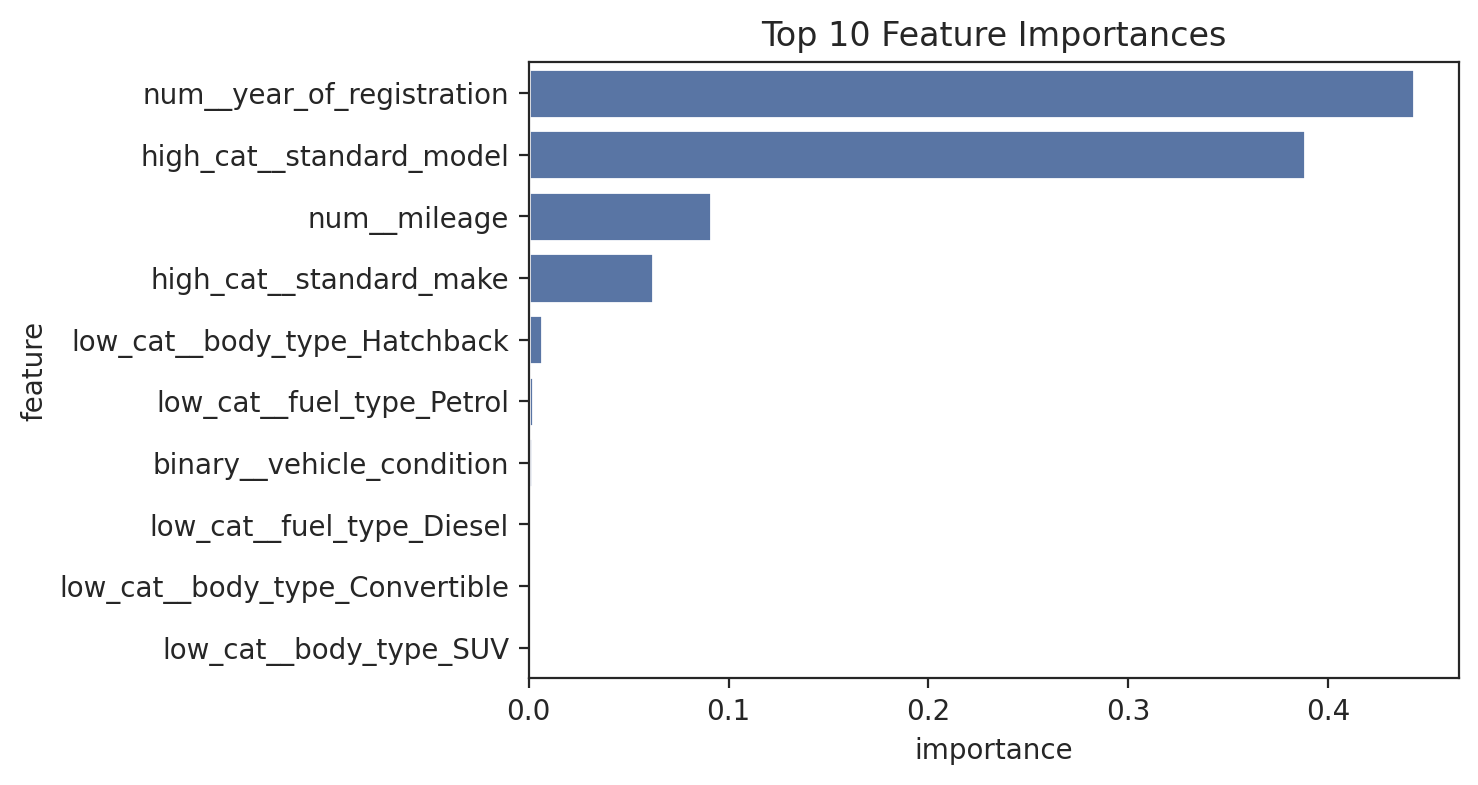

In [65]:
importances = clf_pipe.named_steps['tree_reg'].feature_importances_
feature_names = clf_pipe.named_steps['preprocess'].get_feature_names_out()
feat_ = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

sns.barplot(
    data=feat_.head(10),
    x='importance',
    y='feature'
)
plt.title('Top 10 Feature Importances')
plt.show()


In [31]:
train_score = clf_pipe.score(X_train, y_train_log)
test_score  = clf_pipe.score(X_test, y_test_log)

print("Train R²:", train_score)
print("Test R²:", test_score)

Train R²: 0.9335019255538201
Test R²: 0.925964152816406


In [32]:
log_test = clf_pipe.predict(X_test)

reverse the order for log transformed price to its orignal scale

In [33]:
y_pred = np.expm1(log_test)
y_test_actual = np.expm1(y_test_log)

### Mean absolute score

In [34]:
mean_absolute_error(y_test_actual, y_pred)

2721.692158496798

In [35]:
y_pred_baseline = y_test_actual.mean()

In [36]:
y_pred_baseline

np.float64(17217.647143692244)

In [37]:
np.mean(np.abs((y_test_actual - y_pred_baseline)))

np.float64(10795.899616444487)

### Cross validation score

In [38]:
scores_dict = cross_validate(clf_pipe, X_train, y_train_log, cv=5, return_train_score=True)
scores = pd.DataFrame(scores_dict)
print(scores['train_score'].mean(), scores['train_score'].std())
print(scores['test_score'].mean(), scores['test_score'].std())

0.9331157058982896 0.0003879548775144609
0.9229808795519666 0.0015566717217598658


### Grid Search

In [ ]:
param_grid = {
    'tree_reg__max_depth': [ 1, 3, 4, 8, 10, 12],
    'tree_reg__min_samples_leaf': [ 10, 20, 30 ]
}

In [ ]:
from sklearn.model_selection import ParameterGrid
list(ParameterGrid(param_grid))

In [ ]:
gs = GridSearchCV(clf_pipe, param_grid, return_train_score=True)

In [ ]:
gs_results = gs.fit(X_train, y_train_log)

In [ ]:
gs_df = pd.DataFrame(gs_results.cv_results_)

In [ ]:
gs_df.head(5)

In [ ]:
gs_df_sh = gs_df[ [
    'param_tree_reg__max_depth', 'param_tree_reg__min_samples_leaf',
    'mean_train_score', 'std_train_score',
    'mean_test_score', 'std_test_score', 'rank_test_score'
] ].sort_values('rank_test_score')
gs_df_sh

In [ ]:
gs_results.best_params_

### Linear Regression

In [66]:
LR = LinearRegression()

In [67]:
clf_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('linear_reg', LR)
])

In [68]:
clf_pipe.fit(X_train, y_train_log)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['mileage',
                                                   'year_of_registration']),
                                                 ('low_cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='infrequent_if_exist',
                                                                                 sparse_output=False))]),
                                                  ['body_type', 'fuel_type']),
                                                 ('binary',
                                                  Pipeline(steps=[('ordinal_enc',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['vehicle_condition',
                                                   'crossover_car_and_van']),
                                                 ('high_cat',
                                                  Pipeline(steps=[('tar_enc',
                                                                   TargetEncoder())]),
                                                  ['standard_make',
                                                   'standard_model',
                                                   'standard_colour'])])),
                ('linear_reg', LinearRegression())])

In [42]:
train_score = clf_pipe.score(X_train, y_train_log)
test_score  = clf_pipe.score(X_test, y_test_log)

print("Train R²:", train_score)
print("Test R²:", test_score)

Train R²: 0.8521581348663565
Test R²: 0.853695673959911


### Actual vs Predicted

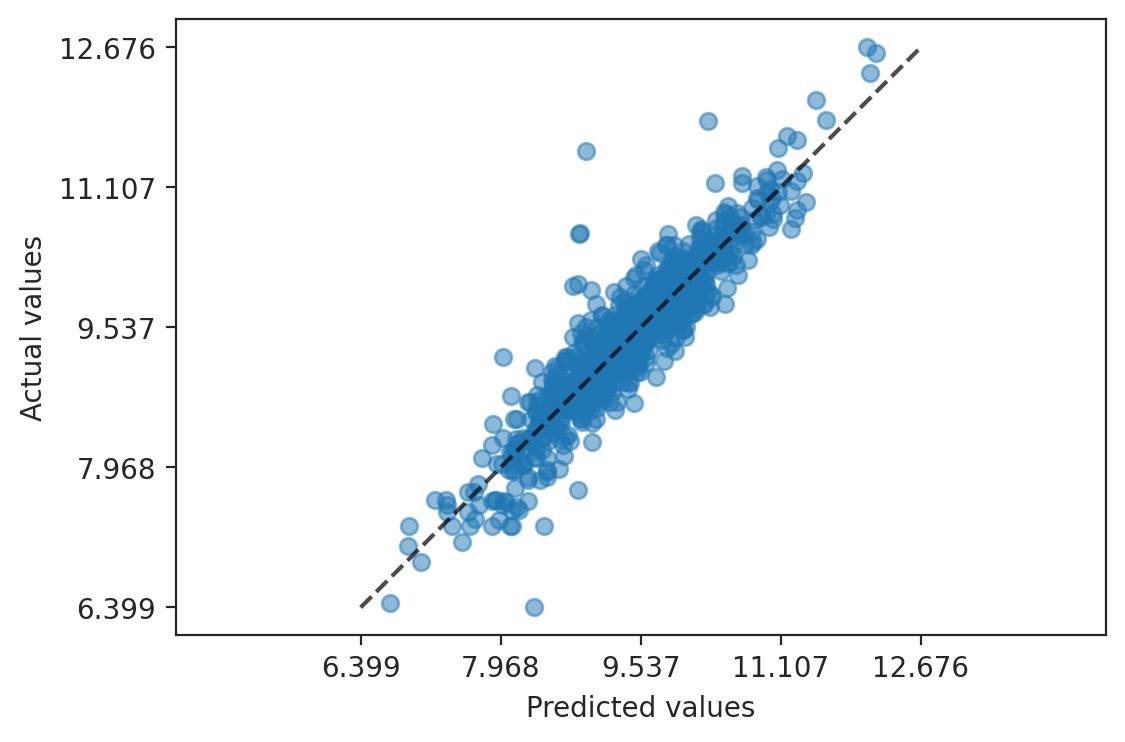

In [43]:
PredictionErrorDisplay.from_estimator(
    clf_pipe, X_test, y_test_log, kind="actual_vs_predicted", scatter_kwargs=dict(alpha=0.5)
);

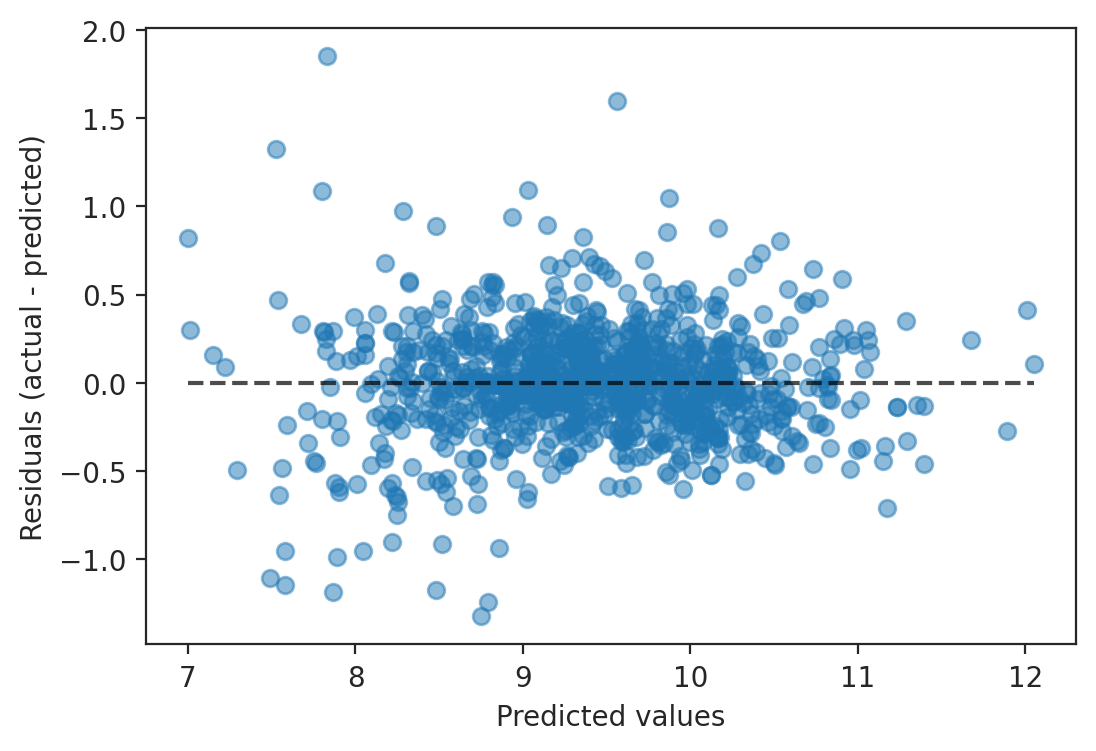

In [44]:
PredictionErrorDisplay.from_estimator(
    clf_pipe, X_test, y_test_log, kind="residual_vs_predicted", scatter_kwargs=dict(alpha=0.5)
);

In [45]:
log_test = clf_pipe.predict(X_test)

In [46]:
y_pred = np.expm1(log_test)
y_test_actual = np.expm1(y_test_log)

In [47]:
residuals = y_test_actual - y_pred

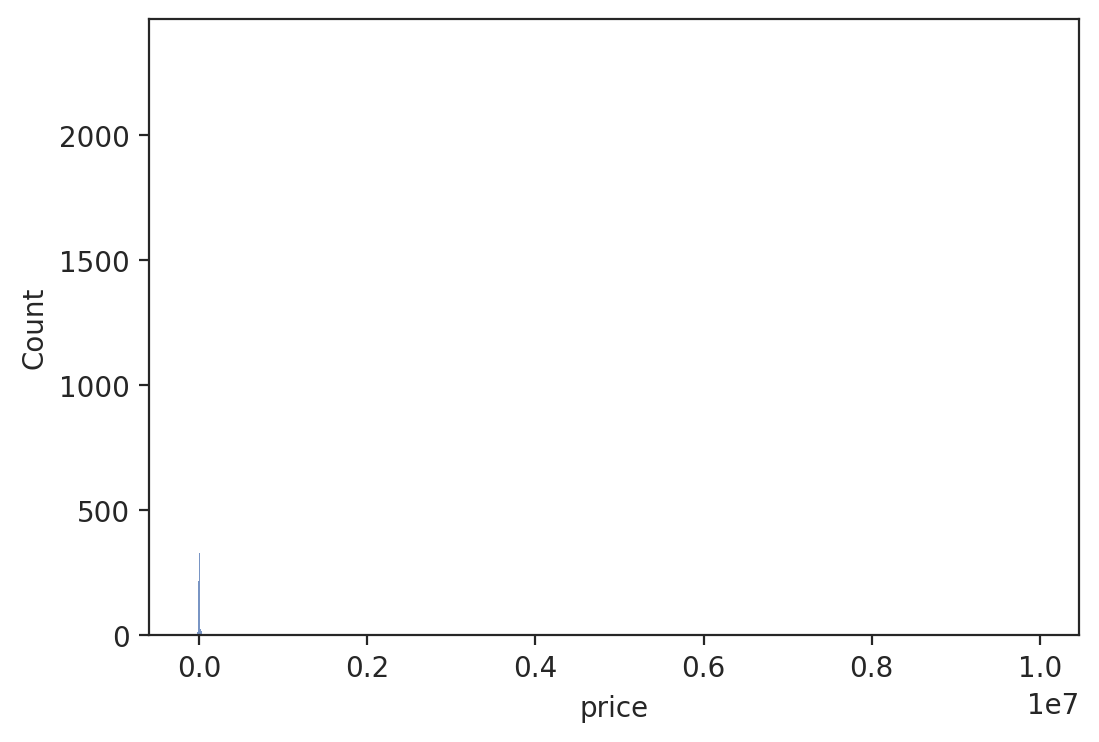

In [48]:
sns.histplot(residuals);

### Cross Validated Score

In [49]:
scores_dict = cross_validate(clf_pipe, X_train, y_train_log, cv=5, return_train_score=True)
scores = pd.DataFrame(scores_dict)
print(scores['train_score'].mean(), scores['train_score'].std())
print(scores['test_score'].mean(), scores['test_score'].std())

0.8513303985455399 0.0006206816421840031
0.850235439079215 0.0025636020101361557


### KNN Regression

In [50]:
knnr = KNeighborsRegressor(n_neighbors=11)

In [51]:
clf_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('knn_reg', knnr)
])

In [52]:
clf_pipe.fit(X_train, y_train_log)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['mileage',
                                                   'year_of_registration']),
                                                 ('low_cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='infrequent_if_exist',
                                                                                 sparse_output=False))]),
                                                  ['body_type', 'fuel_type']),
                                                 ('binary',
                                                  Pipeline(steps=[('ordinal_enc',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['vehicle_condition',
                                                   'crossover_car_and_van']),
                                                 ('high_cat',
                                                  Pipeline(steps=[('tar_enc',
                                                                   TargetEncoder())]),
                                                  ['standard_make',
                                                   'standard_model',
                                                   'standard_colour'])])),
                ('knn_reg', KNeighborsRegressor(n_neighbors=11))])

In [53]:
train_score = clf_pipe.score(X_train, y_train_log)
test_score  = clf_pipe.score(X_test, y_test_log)

print("Train R²:", train_score)
print("Test R²:", test_score)

Train R²: 0.9444758936571567
Test R²: 0.9336850892829465


### Actual vs Predicted

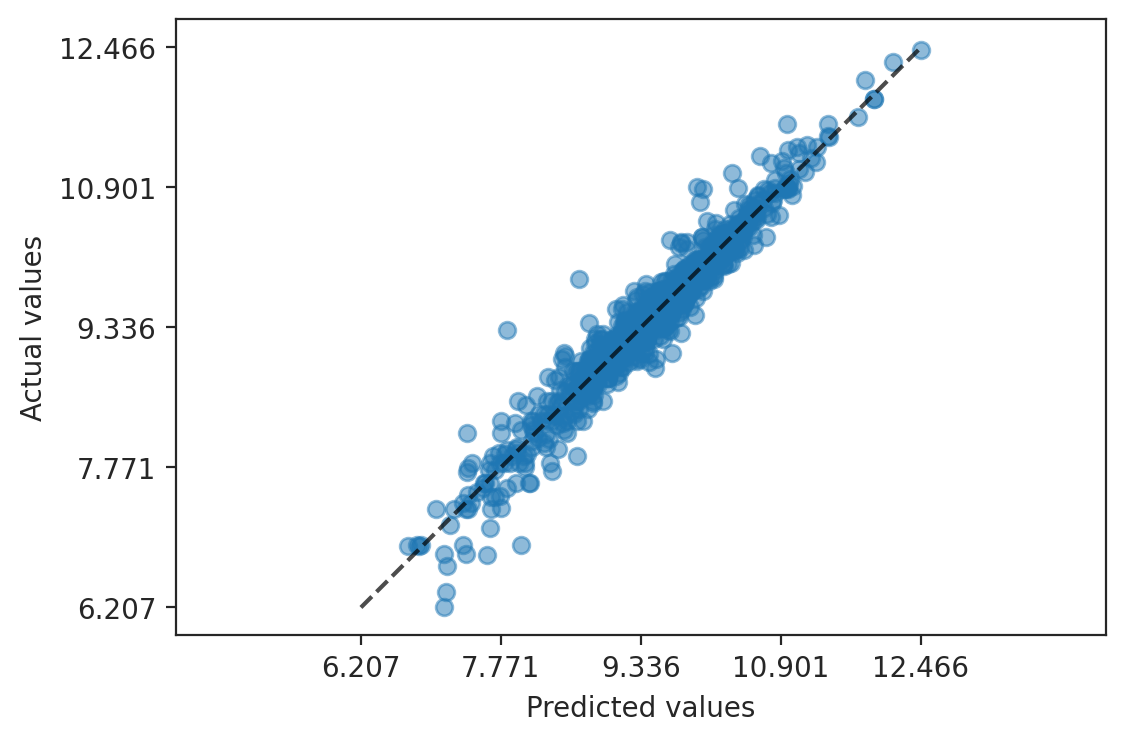

In [54]:
PredictionErrorDisplay.from_estimator(
    clf_pipe, X_test, y_test_log, kind="actual_vs_predicted", scatter_kwargs=dict(alpha=0.5)
);

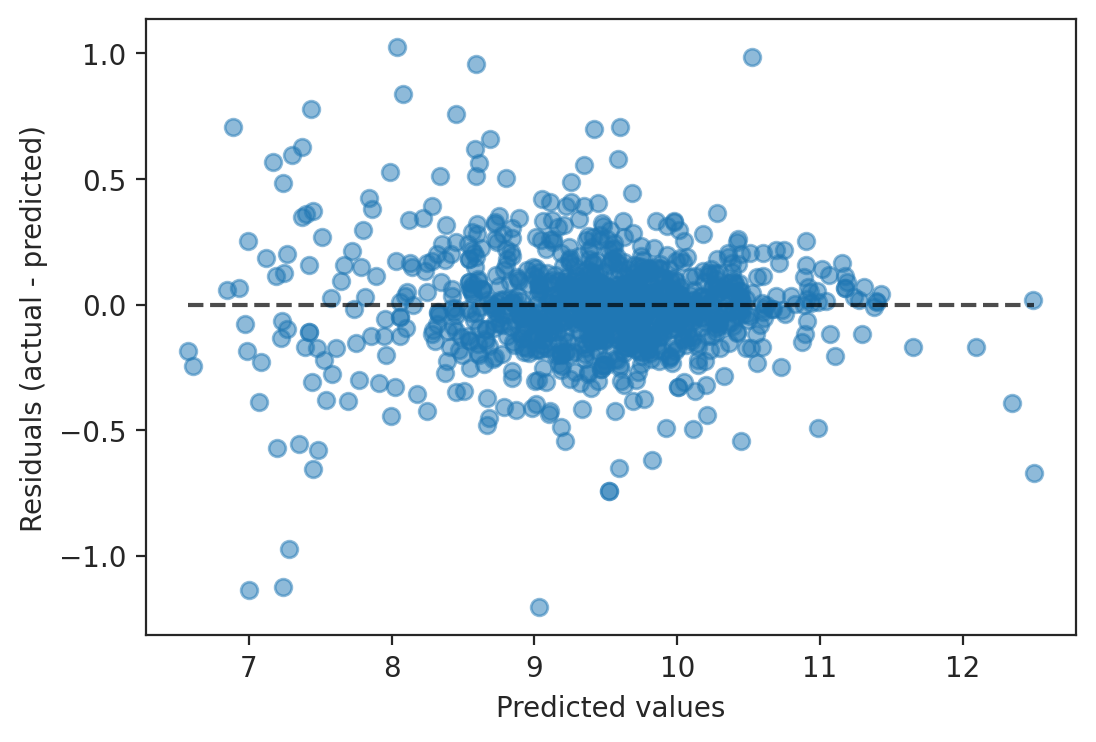

In [55]:
PredictionErrorDisplay.from_estimator(
    clf_pipe, X_test, y_test_log, kind="residual_vs_predicted", scatter_kwargs=dict(alpha=0.5)
);

In [56]:
log_test = clf_pipe.predict(X_test)

In [57]:
y_pred = np.expm1(log_test)
y_test_actual = np.expm1(y_test_log)

In [58]:
residuals = y_test_actual - y_pred

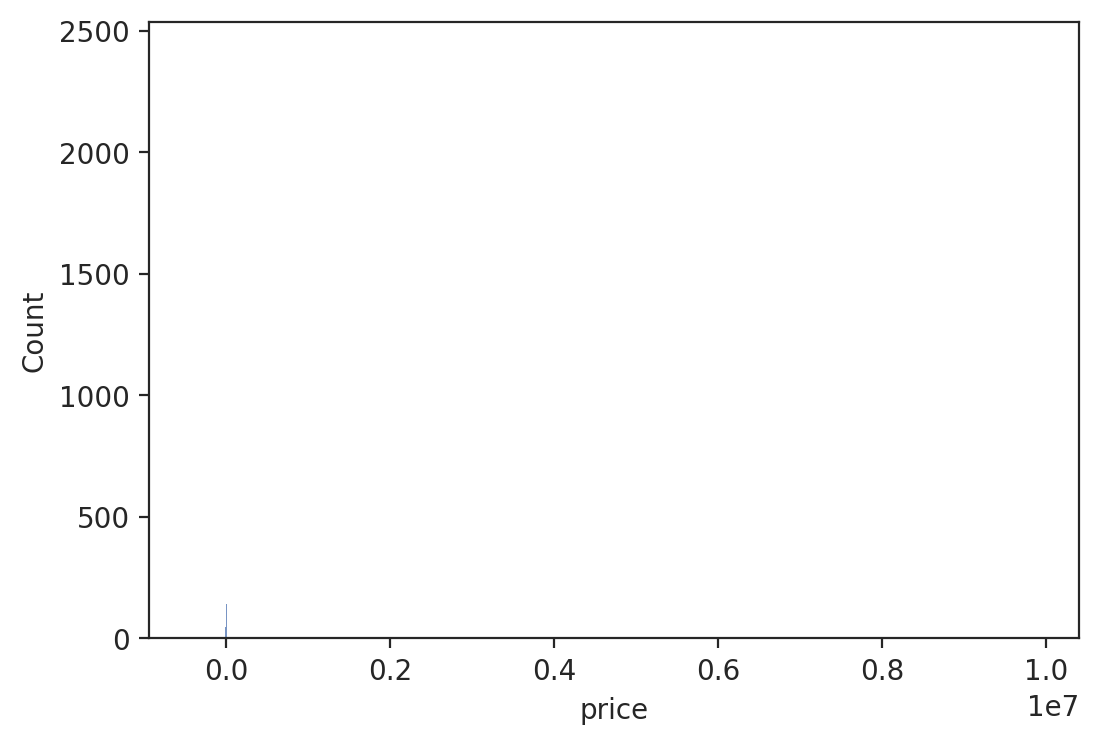

In [59]:
sns.histplot(residuals);

### Cross Validated Score

In [ ]:
scores_dict = cross_validate(clf_pipe, X_train, y_train_log, cv=5, return_train_score=True)
scores = pd.DataFrame(scores_dict)
print(scores['train_score'].mean(), scores['train_score'].std())
print(scores['test_score'].mean(), scores['test_score'].std())